In [1]:
from PIL import Image
import numpy as np
import glob

all_images = []
all_labels = []
filenames = []
ages = []
img_size = (80, 100)
for f in glob.glob('c:\\data\\xray\\**\\*.jpg', recursive=True):
    arr = f.split('\\')
    arr2 = arr[3].split("_")
    if arr2[1] == 'F':
        img = Image.open(f)
        filenames.append(arr[-1])
        img_resize = img.resize((img_size[0], img_size[1]))
        all_images.append(img_resize)
        age = int(arr2[2].replace('yr', ''))
        ages.append(age)

In [2]:
###############################
filenames[:10]

['310_F.jpg',
 '311_F.jpg',
 '312_F.jpg',
 '313_F.jpg',
 '314_F.jpg',
 '315_F.jpg',
 '316_F.jpg',
 '317_F.jpg',
 '318_F.jpg',
 '319_F.jpg']

In [3]:
###############################
items = list(zip(filenames, ages, all_images))
items[:10]

[('310_F.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('311_F.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('312_F.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('313_F.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('314_F.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('315_F.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('316_F.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('317_F.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('318_F.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>),
 ('319_F.jpg', 10, <PIL.Image.Image image mode=RGB size=80x100>)]

In [4]:
###############################
len(all_images)

572

In [5]:
###############################
np.array(all_images[0]).shape

(100, 80, 3)

In [6]:
###############################
X = np.empty((1, img_size[0], img_size[1], 3))
for img in all_images:
    X = np.vstack((X, np.array(img).reshape(1, img_size[0], img_size[1], 3)))
X.shape

(573, 80, 100, 3)

In [7]:
###############################
X = np.delete(X, (0), axis=0)

In [8]:
###############################
X.shape

(572, 80, 100, 3)

In [9]:
###############################
y = np.array(ages)
y[:10]

array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10])

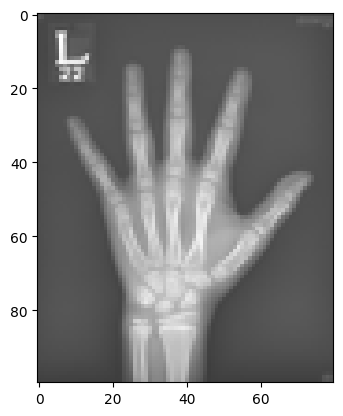

In [10]:
###############################
import matplotlib.pyplot as plt

plt.imshow(all_images[0])
plt.show()

In [11]:
###############################
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=10)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((457, 80, 100, 3), (115, 80, 100, 3), (457,), (115,))

In [17]:
###############################
import pandas as pd

pd.DataFrame(y_train).value_counts().sort_index()

0 
3     15
4     26
5     49
6     40
7     37
8     40
9     40
10    40
11    40
12    40
13    36
14    29
15    15
16    10
Name: count, dtype: int64

In [18]:
###############################
X_train = X_train.reshape(-1, img_size[0] * img_size[1] * 3)
X_test = X_test.reshape(-1, img_size[0] * img_size[1] * 3)

In [19]:
###############################
X_train = X_train / 255.
X_test = X_test / 255.

In [20]:
###############################
X_train = X_train.reshape(-1, img_size[0], img_size[1], 3)
X_test = X_test.reshape(-1, img_size[0], img_size[1], 3)

In [21]:
###############################
from tensorflow.keras import utils

y_train_backup = y_train
y_test_backup = y_test

In [22]:
###############################
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

model = Sequential()
model.add(Conv2D(64, (3, 3), padding="same", input_shape=X_train.shape[1:], activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(Flatten())
model.add(Dense(64, activation="relu"))
model.add(Dense(1))
model.compile(optimizer="rmsprop", loss="mae", metrics=["mae"])
model.summary()

C:\python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 100, 64)    │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 38, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 19, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 17, 22, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 23936)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,531,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,607,681 (6.13 MB)

 Trainable params: 1,607,681 (6.13 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
###############################
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((457, 80, 100, 3), (457,), (115, 80, 100, 3), (115,))

In [24]:
###############################
from keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint("c:/data/models/xray_f_best.keras", monitor='val_loss', verbose=1, save_best_only=True, mode='min')
hist = model.fit(X_train, y_train, batch_size=32, validation_split=0.2, epochs=30, callbacks=[checkpoint])

Epoch 1/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 6.8883 - mae: 6.8883
Epoch 1: val_loss improved from None to 5.20489, saving model to c:/data/models/xray_f_best.keras

Epoch 1: finished saving model to c:/data/models/xray_f_best.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 5.3942 - mae: 5.3942 - val_loss: 5.2049 - val_mae: 5.2049
Epoch 2/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 3.2246 - mae: 3.2246
Epoch 2: val_loss improved from 5.20489 to 3.57712, saving model to c:/data/models/xray_f_best.keras

Epoch 2: finished saving model to c:/data/models/xray_f_best.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - loss: 3.1430 - mae: 3.1430 - val_loss: 3.5771 - val_mae: 3.5771
Epoch 3/30
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 3.5019 - mae: 3.5019
Epoch 3: val_loss improved from 3.57712 to 2.84875, saving model to c:/data/models/xray_f_best.keras

Epoch 3: finished saving model to c:/data/models/xray_f_best.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - lo

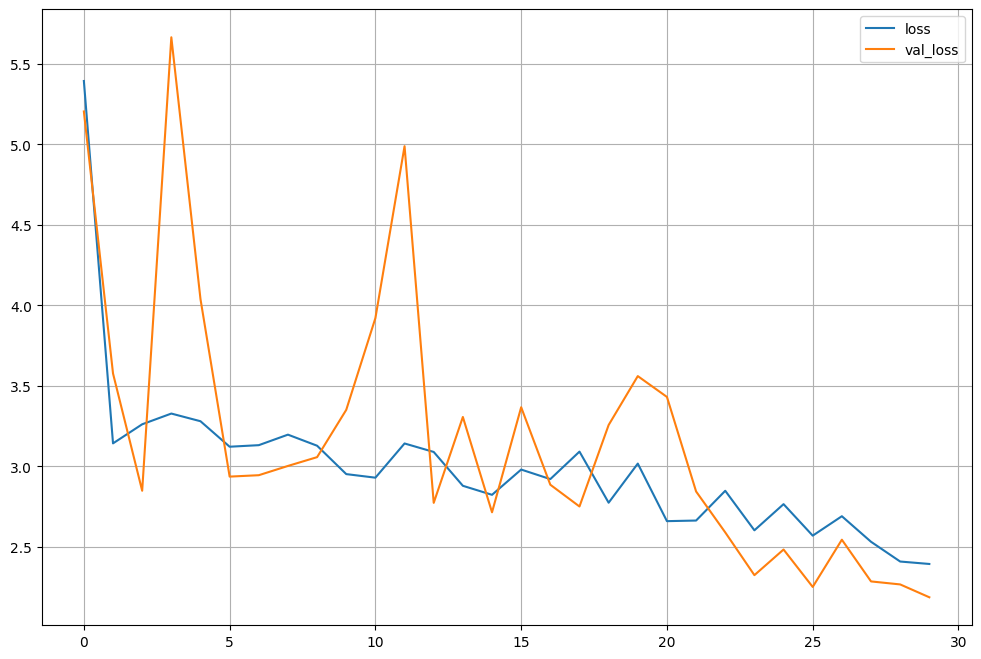

In [25]:
###############################
plt.figure(figsize=(12, 8))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.grid()
plt.show()

In [26]:
###############################
from tensorflow.keras.models import load_model

model = load_model('c:/data/models/xray_f_best.keras')
scores = model.evaluate(X_train, y_train, verbose=1)
print(scores)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 2.1275 - mae: 2.1275
[2.127462863922119, 2.127462863922119]


In [27]:
###############################
model = load_model('c:/data/models/xray_f_best.keras')
scores = model.evaluate(X_test, y_test, verbose=1)
print(scores)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 2.3456 - mae: 2.3456
[2.3455748558044434, 2.3455748558044434]


In [28]:
###############################
pred = model.predict(X_test)
pred[:5]

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


array([[5.4140096],
       [4.9211926],
       [9.905766 ],
       [8.47218  ],
       [9.038752 ]], dtype=float32)

In [29]:
###############################
y_test[:5]

array([ 5,  4, 15, 13, 10])